In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]


/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
from comparing_slice_TCA_methods import *

In [3]:
data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)

data_truncated_array_NDNF.shape


(115, 50, 100)

In [4]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")

In [5]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl"

with open (save_path, 'rb') as f:
    model_and_mse_dict_NDNF = pickle.load(f)
    print(save_path)

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl


In [12]:
len(model_and_mse_dict_NDNF)

40

In [6]:
model_20_NDNF_raw_0x0 = model_and_mse_dict_NDNF[20]['model']

In [7]:
# labels_cells_dict_all_K_EC_x00_raw = get_labels_all_different_Ks_single(model_20_EC_raw_x00, which_vectors=0)
labels_cells_dict_all_K_NDNF_0x0_raw = get_labels_all_different_Ks_single(model_20_NDNF_raw_0x0, which_vectors=1)
# labels_cells_dict_all_K_EC_00x_raw = get_labels_all_different_Ks_single(model_20_EC_raw_00x, which_vectors=2)

# labels_cells_dict_all_K_EC_x00_resid = get_labels_all_different_Ks_single(model_20_EC_resid_x00, which_vectors=0)
# labels_cells_dict_all_K_EC_0x0_resid = get_labels_all_different_Ks_single(model_20_EC_resid_0x0, which_vectors=1)
# labels_cells_dict_all_K_EC_00x_resid = get_labels_all_different_Ks_single(model_20_EC_resid_00x, which_vectors=2)

F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


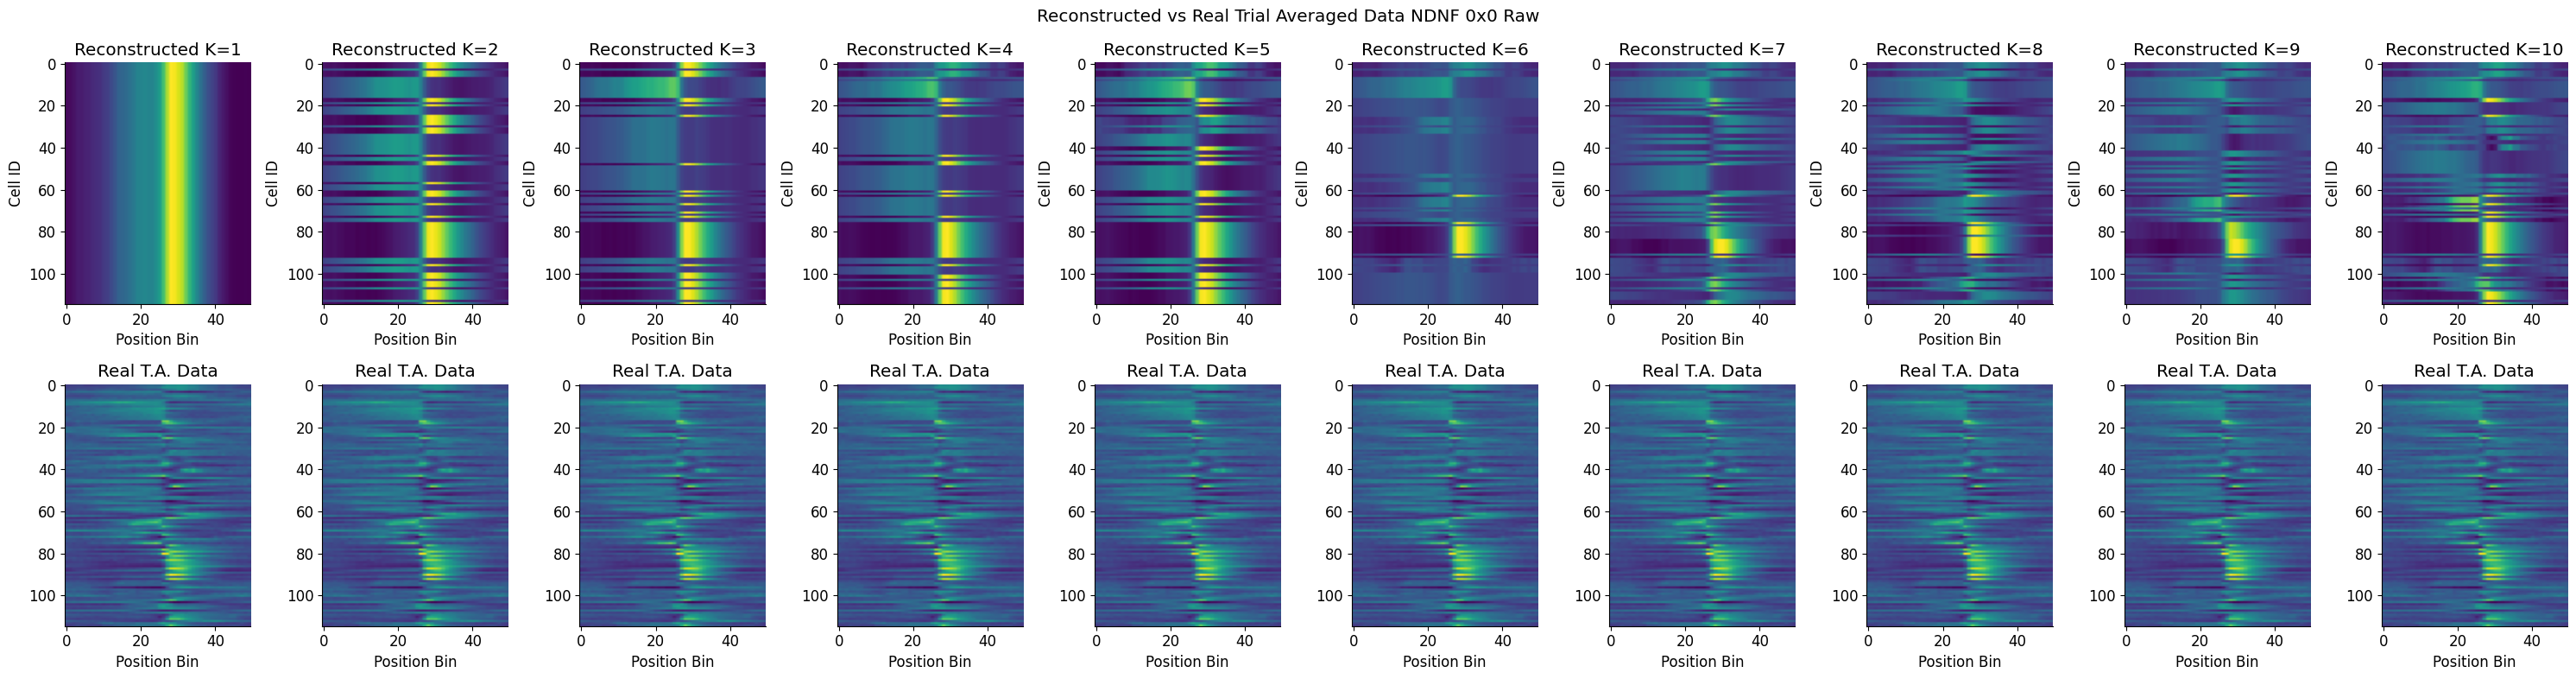

In [16]:
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_raw, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Raw")


F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


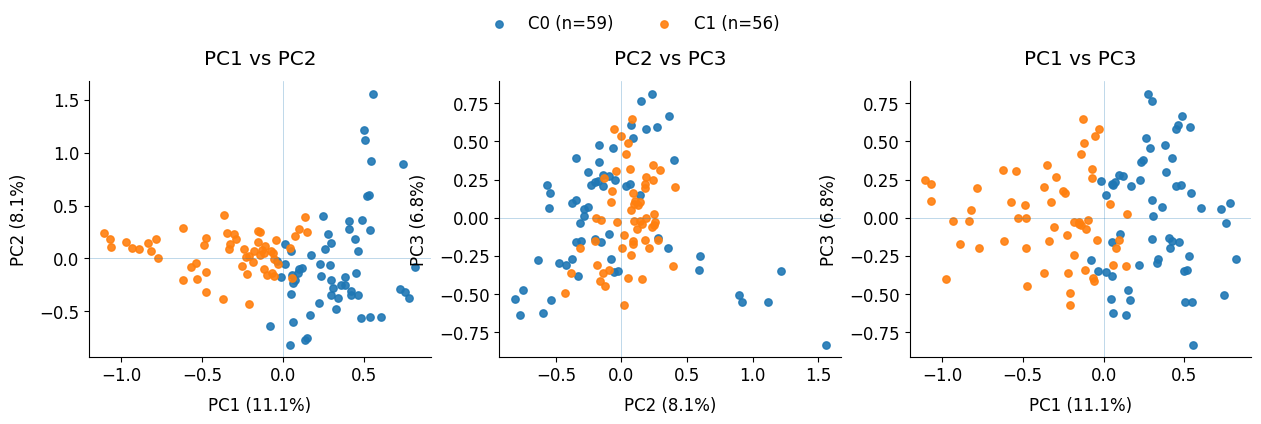

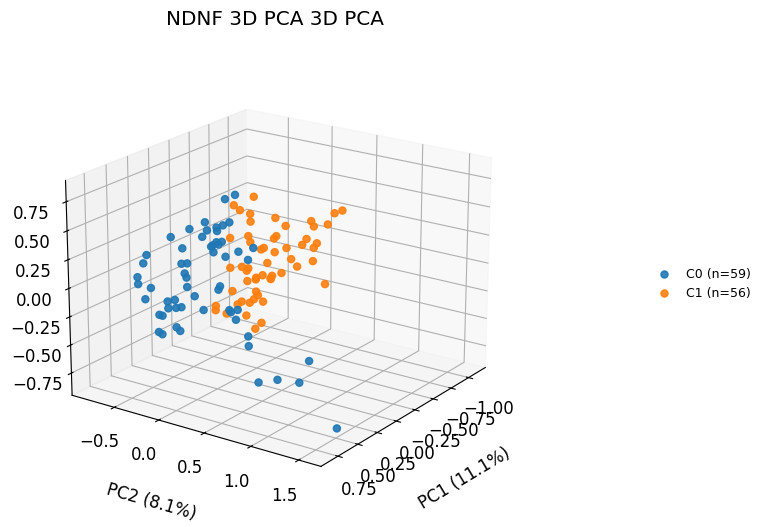

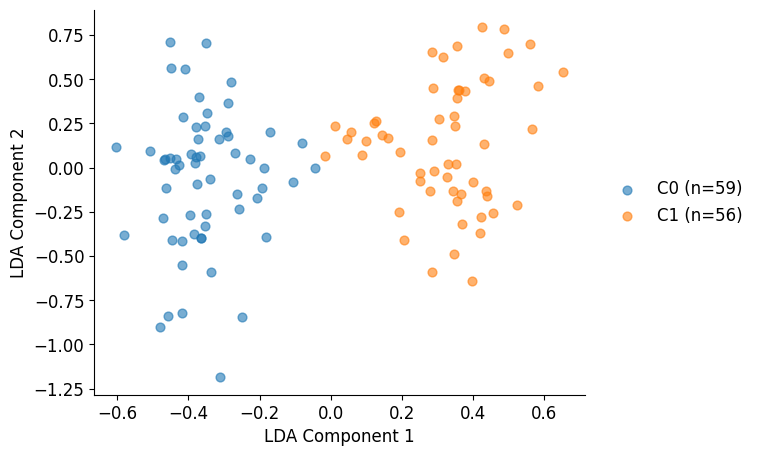

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


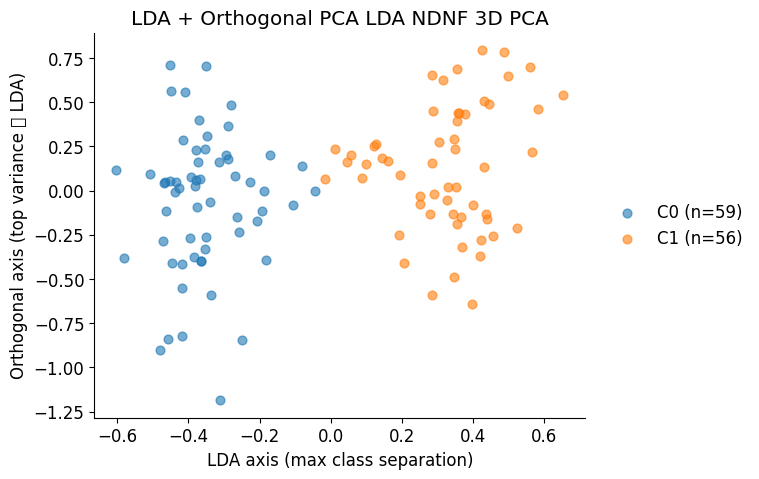

In [9]:
out = pca_cluster_viz(
    model_20_NDNF_raw_0x0,
    which_vectors=1,
    feature_space="loadings",     # or whatever you’re using in get_cell_features
    feature_mode="0x0",     # your existing arg
    n_cells_expected=115,         # fill with your expected count
    n_latents_expected=20,       # fill with your expected count
    n_components=3,
    num_clusters=2,               # <= set 2 if you want the LDA+orth trick; ≥3 uses LDA(2)
    title_prefix="NDNF 3D PCA")


array([1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1], dtype=int32)

In [13]:

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells'
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells'
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)


mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell'
cell_NDNF_model_ranks20_contig_x00_cue = get_model_data_per_cell(mse_dir)

    
fixed_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_cue[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_contig_x00_cue[20][animal-18] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict


cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

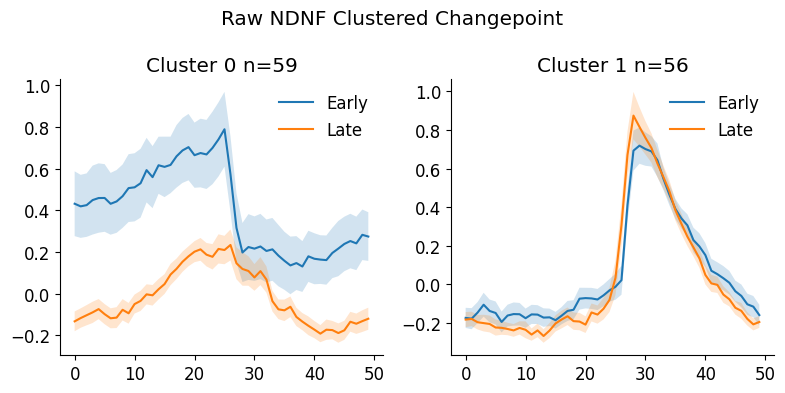

In [18]:
activity_early_array, activity_array_late = get_activity_cut_learn(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw NDNF Clustered Changepoint")

# activity_early_array_resid, activity_array_late_resid = get_activity_cut_learn(residual_activity_dict_SST, cp_dict_NDNF)
# plot_clustered_data_learn(means_dict_cluster_0x0_resid, activity_early_array_resid, activity_array_late_resid, K=2, title="Residuals SST Clustered Changepoint 0x0")



In [19]:
cell_type_labels = labels_cells_dict_all_K_NDNF_0x0_raw[2]

cells_group_0 = np.where(cell_type_labels==0)[0]
cells_group_1 = np.where(cell_type_labels==1)[0]

print(cells_group_0)
print(cells_group_1)

[  3   7   8   9  10  11  12  13  14  15  16  19  21  22  23  24  30  34
  35  36  37  38  39  40  41  42  43  45  46  49  50  51  52  53  54  55
  56  58  59  60  64  65  66  68  69  70  71  72  74  75  93  94  95  97
  98  99 103 107 113]
[  0   1   2   4   5   6  17  18  20  25  26  27  28  29  31  32  33  44
  47  48  57  61  62  63  67  73  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  96 100 101 102 104 105 106 108 109 110 111
 112 114]


In [21]:
# mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell'
# testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

# mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell'
# testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell'
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 8 cells
    Animal 22: 8 cells
    Animal 23: 9 cells
    Animal 24: 12 cells
    Animal 25: 13 cells
    Animal 26: 8 cells
    Animal 27: 9 cells
    Animal 28: 8 cells
    Animal 29: 8 cells
    Animal 30: 6 cells
    Animal 31: 11 cells
    Animal 32: 13 cells
    Animal 33: 19 cells
    Animal 34: 8 cells
    Animal 35: 12 cells
    Animal 36: 6 cells
    Animal 37: 9 cells
    Animal 38: 10 cells


In [ ]:
trial_type_data = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]

fixed_TT_data = {}
for idx, animal in enumerate(trial_type_data):
    if 17 < idx < 31:
        fixed_TT_data[f"animal_{idx+1}"] = trial_type_data[animal]


dict_keys(['animal_19', 'animal_20', 'animal_21', 'animal_22', 'animal_23', 'animal_24', 'animal_25', 'animal_26', 'animal_27', 'animal_28', 'animal_29', 'animal_30', 'animal_31'])

In [163]:


def get_max_proportion(early_labels, use_max=True):
    unique_early_labels = np.unique(early_labels)
    if use_max:
        og_proportion=0
    else:
        og_proportion=1000
    good_dict=None
    for unique_label in unique_early_labels:
        amount = len(np.where(early_labels==unique_label)[0])
        len_early_labels = len(early_labels)
        proportion_early = amount / len_early_labels

        if use_max:
            if proportion_early > og_proportion:
                good_dict= {"unique_label":unique_label,
                        "fraction":proportion_early}
                og_proportion=proportion_early
        else:
            if proportion_early < og_proportion:
                good_dict= {"unique_label":unique_label,
                        "fraction":proportion_early}
                og_proportion=proportion_early
    return good_dict


In [246]:
def get_lists_out_of_dicts(fixed_TT_data, fixed_activity_dict_NDNF_newest, cp_dict_NDNF):
    TT_list = []
    for animal in fixed_TT_data:
        for cell in fixed_TT_data[animal]:
            TT_list.append(fixed_TT_data[animal][cell][1][f"cell_{cell}"])

    print(len(TT_list)) 

    NDNF_activity_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            NDNF_activity_list.append(fixed_activity_dict_NDNF_newest[animal][cell])

    print(len(NDNF_activity_list)) 

    cp_list_NDNF = []

    for animal in cp_dict_NDNF:
        for cell in cp_dict_NDNF[animal]:
            cp_list_NDNF.append(cp_dict_NDNF[animal][cell])

    print(len(cp_list_NDNF)) 

    return TT_list, NDNF_activity_list, cp_list_NDNF

TT_list, NDNF_activity_list, cp_list_NDNF = get_lists_out_of_dicts(fixed_TT_data, fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)


115
115
115


In [247]:
def get_elbow_score_data(new_cell_SST_model_ranks20_kmeans_reassign_x00, animal=0, cell=0):
    MSE_dict = new_cell_SST_model_ranks20_kmeans_reassign_x00[20][animal][cell][1][f"cell_{cell}"]['MSE_dict']

    MSE_list = []
    for clusters_chosen in MSE_dict:
        MSE_list.append(MSE_dict[clusters_chosen])
    MSE_array = np.array(MSE_list)

    elbow_kmeans = find_elbow_point(MSE_array)

    return elbow_kmeans

def find_elbow_point(y_vals, min_index=2):
    from scipy.spatial.distance import cdist
    import numpy as np

    x = np.arange(len(y_vals))
    y = y_vals

    # First and last points
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    # Compute distances to the line
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    vec_from_p1 = np.vstack((x - p1[0], y - p1[1])).T
    scalar_proj = np.dot(vec_from_p1, line_vec_norm)
    proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.linalg.norm(vec_from_p1 - proj, axis=1)

    # Force elbow to be at least min_index (default = 2)
    elbow_idx = np.argmax(dist_to_line[min_index:]) + min_index
    return int(elbow_idx)



In [ ]:
def get_most_expressed_cluster(TT_list, activity_list, cp_list_NDNF, early_late_none="early", to_include=None, most_expressed=True):
    
    if np.any(to_include) == None:
        indices_to_include = np.arange(115)
    else:
        indices_to_include = to_include

    most_expressed_label_dict = {}

    elbow_kmeans_array = np.empty(len(indices_to_include))

    for j, cell in enumerate(indices_to_include):
              
        activity_array = activity_list[cell]

        labels_example = TT_list[cell]["labels_dict"]["clusters_chosen_3"]

        MSE_dict = TT_list[cell]["MSE_dict"]

        MSE_array = np.empty(len(MSE_dict))

        for id, clusters_chosen in enumerate(MSE_dict):
            MSE = MSE_dict[clusters_chosen]
            MSE_array[id] = MSE
        
        elbow_kmeans = find_elbow_point(MSE_array)

        elbow_kmeans_array[j] = elbow_kmeans
        
        if early_late_none=='early':
            cp_early = cp_list_NDNF[cell][0]
            labels = labels_example[:cp_early]

        elif early_late_none=='late':
            cp_late = cp_list_NDNF[cell][1]
            labels = labels_example[cp_late:]

        elif early_late_none=='none':
            labels = labels_example
        else:
            raise ValueError("Invalid learning chunk")


        good_dict = get_max_proportion(labels, use_max=most_expressed)

        correct_indices = np.where(labels==good_dict["unique_label"])[0]
        activity_array_sliced = activity_array[:,correct_indices]


        most_expressed_label_dict[cell] = {"label":good_dict["unique_label"],
                                                        "cluster_activity": activity_array_sliced, "fraction":good_dict["fraction"]}

    return most_expressed_label_dict, elbow_kmeans_array
    
most_expressed=True

most_expressed_label_dict_animal_early, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="early", most_expressed=most_expressed)
most_expressed_label_dict_animal_late, elbow_kmeans_array = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="late", most_expressed=most_expressed)


most_expressed_label_dict_animal_early_group0, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="early", to_include=cells_group_0, most_expressed=most_expressed)
most_expressed_label_dict_animal_late_group0, elbow_kmeans_array_group0 = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="late", to_include=cells_group_0, most_expressed=most_expressed)


most_expressed_label_dict_animal_early_group1, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="early", to_include=cells_group_1, most_expressed=most_expressed)
most_expressed_label_dict_animal_late_group1, elbow_kmeans_array_group1 = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="late", to_include=cells_group_1, most_expressed=most_expressed)





def plot_no_learn_cell_types(most_expressed_label_dict_animal_cluster_0_all, most_expressed_label_dict_animal_cluster_1_all, elbow_kmeans_array, group=None, most_expressed=most_expressed):

    fig, axs = plt.subplots(3,2, figsize=(8,10))

    if most_expressed:
        fig.suptitle("Most Highly Expressed Cluster Per Cell")
    else:
        fig.suptitle("Least Highly Expressed Cluster Per Cell")

    fig.suptitle(group)

    mean_0_list = []
    mean_1_list = []

    mean_0_fractions_list = []
    mean_1_fractions_list = []

    for cell in most_expressed_label_dict_animal_cluster_0_all:
        array0 = most_expressed_label_dict_animal_cluster_0_all[cell]["cluster_activity"]
        mean0 = np.mean(array0, axis=1)
        mean_0_list.append(mean0)
        axs[0,0].plot(mean0)
        mean_0_fractions_list.append(most_expressed_label_dict_animal_cluster_0_all[cell]["fraction"])
    for cell in most_expressed_label_dict_animal_cluster_1_all:
        array1 = most_expressed_label_dict_animal_cluster_1_all[cell]["cluster_activity"]
        mean1 = np.mean(array1, axis=1)
        mean_1_list.append(mean1)
        axs[0,1].plot(mean1)
        mean_1_fractions_list.append(most_expressed_label_dict_animal_cluster_1_all[cell]["fraction"])



    axs[0,0].set_title("Group0")
    axs[0,1].set_title("Group1")

    mean_0_array = np.array(mean_0_list)
    mean_1_array = np.array(mean_1_list)

    mean_mean_0_array = np.mean(mean_0_array, axis=0)
    mean_mean_1_array = np.mean(mean_1_array, axis=0)

    sem_0_array = sem(mean_0_array, axis=0)
    sem_1_array = sem(mean_1_array, axis=0)

    axs[1,0].plot(mean_mean_0_array, label='Group0')
    axs[1,1].plot(mean_mean_1_array, label='Group1')
    axs[1,0].fill_between(range(len(mean_mean_0_array)), mean_mean_0_array-sem_0_array, mean_mean_0_array+sem_0_array, alpha=0.2)
    axs[1,1].fill_between(range(len(mean_mean_1_array)), mean_mean_1_array-sem_1_array, mean_mean_1_array+sem_1_array, alpha=0.2)

    axs[2,0].hist(mean_0_fractions_list)
    axs[2,0].set_xlabel("Fraction of Total Trials")
    axs[2,0].set_ylabel("Cells")

    axs[2,1].hist(mean_1_fractions_list)
    axs[2,1].set_xlabel("Fraction of Total Trials")
    axs[2,1].set_ylabel("Cells")

    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1,2, figsize=(15,5))



    axs[0].plot(mean_mean_0_array, label='Early')
    axs[0].plot(mean_mean_1_array, label='Late')
    axs[0].fill_between(range(len(mean_mean_0_array)), mean_mean_0_array-sem_0_array, mean_mean_0_array+sem_0_array, alpha=0.2)
    axs[0].fill_between(range(len(mean_mean_1_array)), mean_mean_1_array-sem_1_array, mean_mean_1_array+sem_1_array, alpha=0.2)
    axs[0].set_title(group)
    axs[0].legend()

    axs[1].hist(elbow_kmeans_array)
    axs[1].set_title("Early Elbow Num Clusters Distribution")
        
    plt.tight_layout()
    plt.show()



def plot_early_late_activity(most_expressed_label_dict_animal_early, most_expressed_label_dict_animal_late, elbow_kmeans_array, group=None, most_expressed=most_expressed):

    fig, axs = plt.subplots(2,2)

    if most_expressed:
        plt.suptitle("Most Highly Expressed Cluster Per Cell")
    else:
        plt.suptitle("Most Highly Expressed Cluster Per Cell")

    fig.suptitle(group)

    mean_early_list = []
    mean_late_list = []

    for cell in most_expressed_label_dict_animal_early:
        early_array = most_expressed_label_dict_animal_early[cell]["cluster_activity"]
        mean_early = np.mean(early_array, axis=1)
        mean_early_list.append(mean_early)
        late_array = most_expressed_label_dict_animal_late[cell]["cluster_activity"]
        mean_late = np.mean(late_array, axis=1)
        mean_late_list.append(mean_late)
        axs[0,0].plot(mean_early)
        axs[0,1].plot(mean_late)

    axs[0,0].set_title("Early")
    axs[0,1].set_title("Late")

    mean_early_array = np.array(mean_early_list)
    mean_late_array = np.array(mean_late_list)

    mean_mean_early_array = np.mean(mean_early_array, axis=0)
    mean_mean_late_array = np.mean(mean_late_array, axis=0)

    sem_early_array = sem(mean_early_array, axis=0)
    sem_late_array = sem(mean_late_array, axis=0)

    axs[1,0].plot(mean_mean_early_array, label='Early')
    axs[1,1].plot(mean_mean_late_array, label='Late')
    axs[1,0].fill_between(range(len(mean_mean_early_array)), mean_mean_early_array-sem_early_array, mean_mean_early_array+sem_early_array, alpha=0.2)
    axs[1,1].fill_between(range(len(mean_mean_late_array)), mean_mean_late_array-sem_late_array, mean_mean_late_array+sem_late_array, alpha=0.2)


    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1,3, figsize=(15,5))



    axs[0].plot(mean_mean_early_array, label='Early')
    axs[0].plot(mean_mean_late_array, label='Late')
    axs[0].fill_between(range(len(mean_mean_early_array)), mean_mean_early_array-sem_early_array, mean_mean_early_array+sem_early_array, alpha=0.2)
    axs[0].fill_between(range(len(mean_mean_late_array)), mean_mean_late_array-sem_late_array, mean_mean_late_array+sem_late_array, alpha=0.2)
    axs[0].set_title(group)
    axs[0].legend()

    eval_proportion(most_expressed_label_dict_animal_early, most_expressed_label_dict_animal_late, group="All Cells", ax=axs[1])

    axs[2].hist(elbow_kmeans_array)
    axs[2].set_title("Early Elbow Num Clusters Distribution")
    axs[2].set_xlabel("Number of Clusters")
    axs[2].set_ylabel("Number of Cells")

    plt.tight_layout()
    plt.show()

    



In [249]:
for cell in most_expressed_label_dict_animal_all_group0:
    print(most_expressed_label_dict_animal_all_group0[cell]["fraction"])

0.37383177570093457
0.7564102564102564
0.49230769230769234
0.48717948717948717
0.5230769230769231
0.5230769230769231
0.4948717948717949
0.48205128205128206
0.6846153846153846
0.5794871794871795
0.4230769230769231
0.5
0.6046511627906976
0.6395348837209303
0.37790697674418605
0.45930232558139533
0.41358024691358025
0.4051724137931034
0.7672413793103449
0.6810344827586207
0.45689655172413796
0.3448275862068966
0.4482758620689655
0.6724137931034483
0.3448275862068966
0.7444444444444445
0.7055555555555556
0.4166666666666667
0.5722222222222222
0.4666666666666667
0.5055555555555555
0.5327868852459017
0.36885245901639346
0.6557377049180327
0.7377049180327869
0.39344262295081966
0.39344262295081966
0.7213114754098361
0.3442622950819672
0.38524590163934425
0.5625
0.3828125
0.3984375
0.7890625
0.640625
0.40625
0.4375
0.40625
0.609375
0.5
0.410958904109589
0.8356164383561644
0.952054794520548
0.863013698630137
0.5205479452054794
0.5205479452054794
0.41025641025641024
0.5282051282051282
0.61


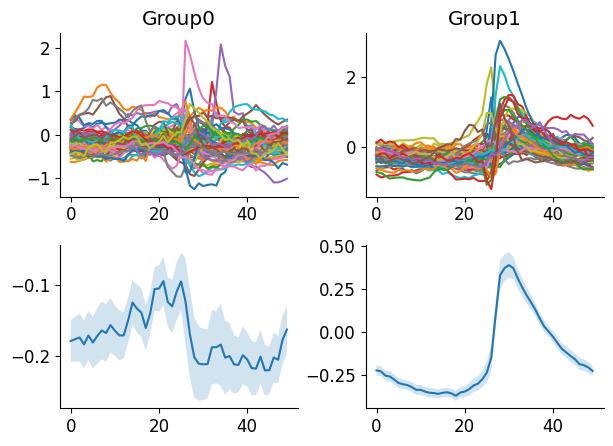

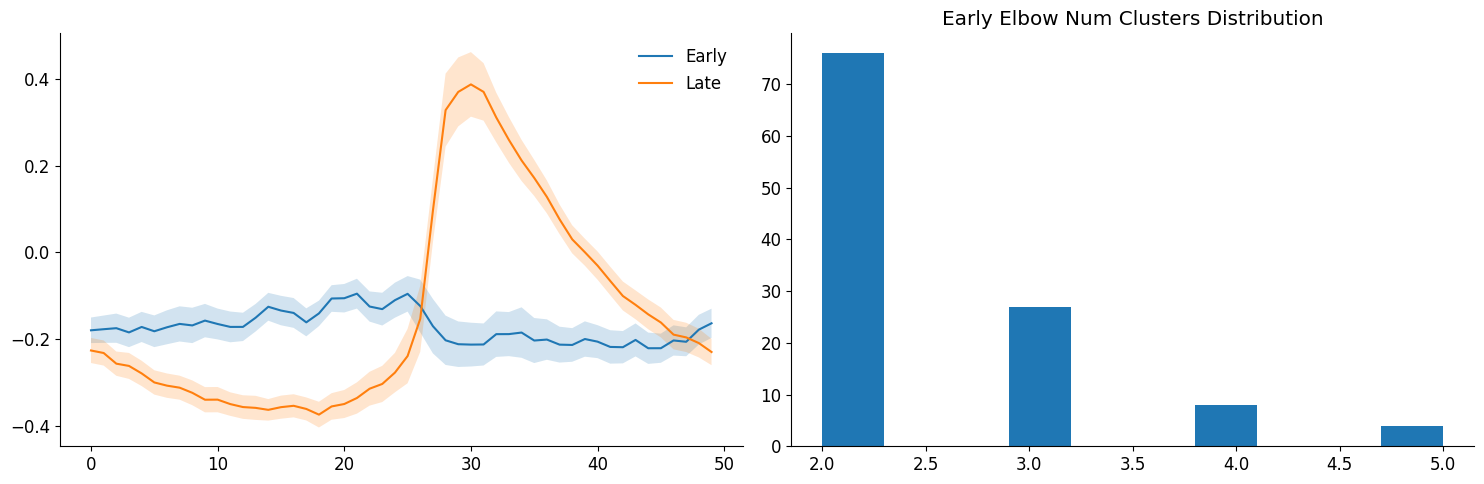

In [250]:


most_expressed_label_dict_animal_all_group0, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="none", to_include=cells_group_0, most_expressed=most_expressed)
most_expressed_label_dict_animal_all_group1, elbow_kmeans_array_group1 = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="none", to_include=cells_group_1, most_expressed=most_expressed)

plot_no_learn_cell_types(most_expressed_label_dict_animal_all_group0, most_expressed_label_dict_animal_all_group1, elbow_kmeans_array, group=None, most_expressed=most_expressed)


In [251]:
from scipy.stats import ttest_rel

def eval_proportion(most_expressed_label_dict_animal_early, most_expressed_label_dict_animal_late, group=None, ax=None):
    early_vals = []
    late_vals  = []

    for cell in most_expressed_label_dict_animal_early:
        early_vals.append(most_expressed_label_dict_animal_early[cell]["fraction"])
        late_vals.append(most_expressed_label_dict_animal_late[cell]["fraction"])

    early_vals = np.array(early_vals)
    late_vals  = np.array(late_vals)

    # paired t test
    t,p = ttest_rel(early_vals, late_vals)

    # plot all individual paired points
    for e,l in zip(early_vals, late_vals):
        ax.plot([0,1], [e,l], color='gray', alpha=0.4)
        ax.plot(0, e, 'o', color='black')
        ax.plot(1, l, 'o', color='black')

    # plot means
    ax.plot([0,1], [early_vals.mean(), late_vals.mean()],
            color='red', marker='o', linewidth=2)

    ax.set_xticks([0,1])
    ax.set_xticklabels(['Early','Late'])
    ax.set_ylabel("Fraction of Trials in Learning Block")
    ax.set_title(f"{group} Paired t-test (p = {p:.3f})")

   

# eval_proportion(most_expressed_label_dict_animal_early, most_expressed_label_dict_animal_late, group="All Cells")
# eval_proportion(most_expressed_label_dict_animal_early_group1, most_expressed_label_dict_animal_late_group1, "Cell Type 1")
# eval_proportion(most_expressed_label_dict_animal_early_group0, most_expressed_label_dict_animal_late_group0, "Cell Type 0")


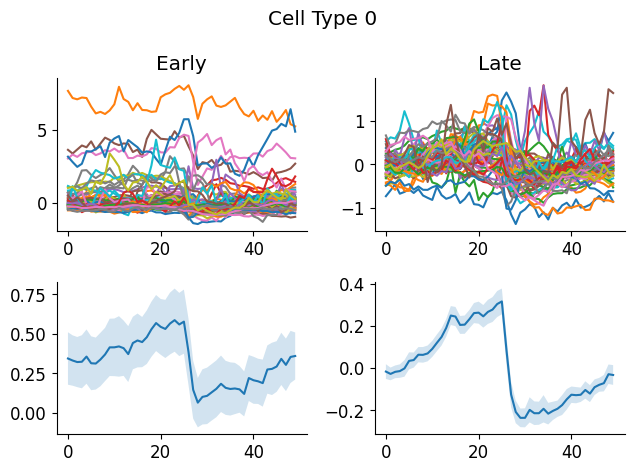

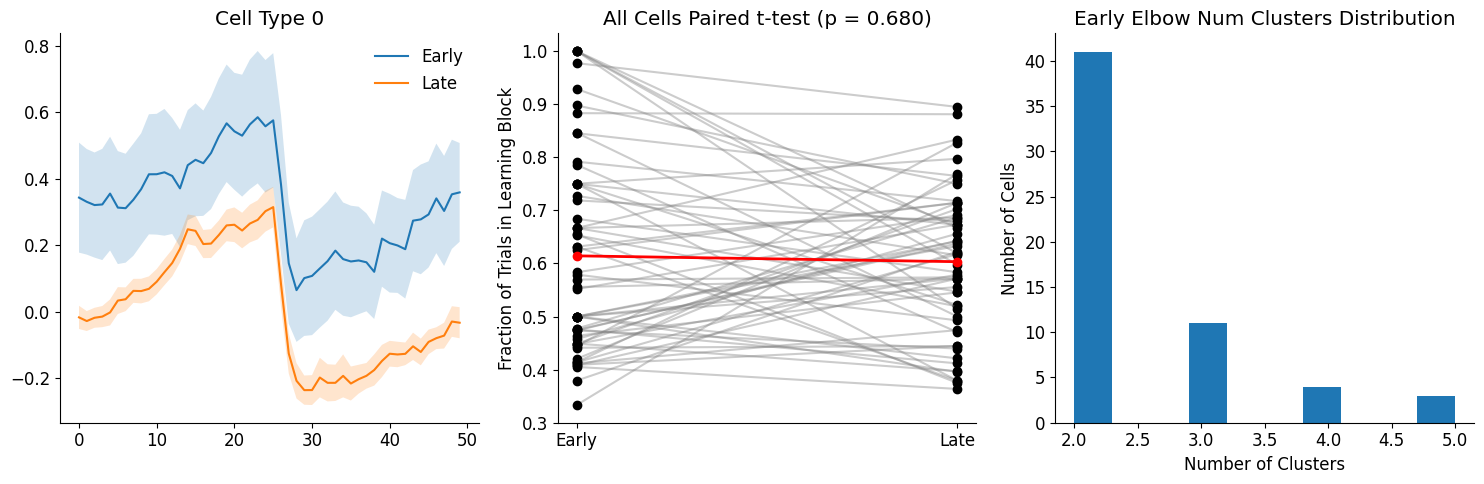

In [252]:

plot_early_late_activity(most_expressed_label_dict_animal_early_group0, most_expressed_label_dict_animal_late_group0, elbow_kmeans_array_group0, group="Cell Type 0")




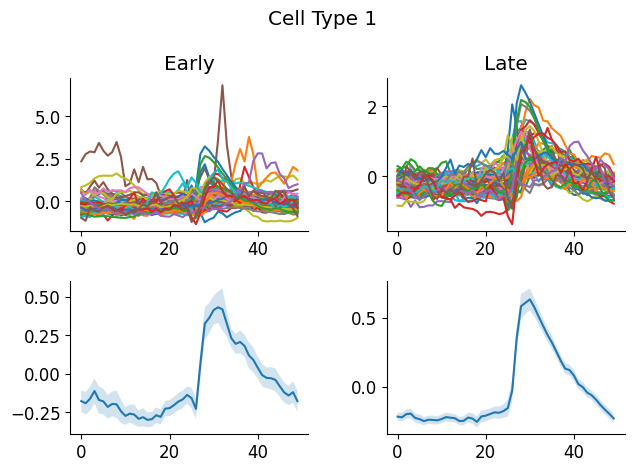

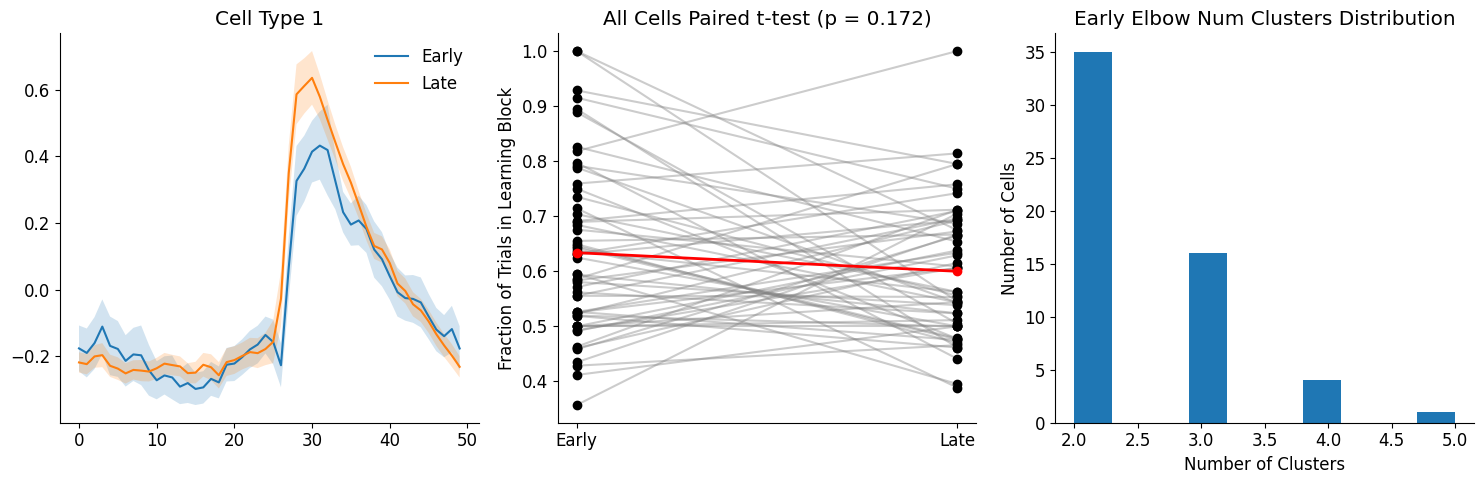

In [253]:

plot_early_late_activity(most_expressed_label_dict_animal_early_group1, most_expressed_label_dict_animal_late_group1, elbow_kmeans_array_group1, group="Cell Type 1")


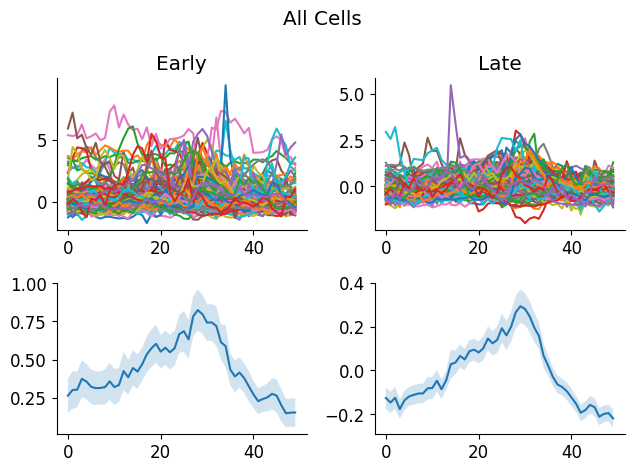

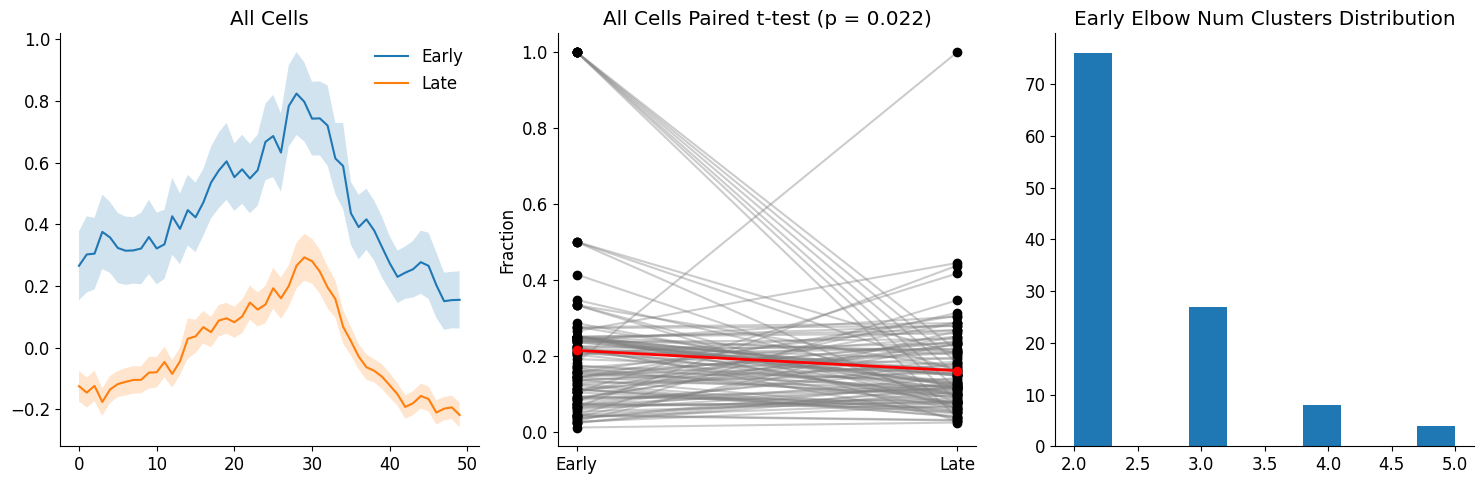

In [224]:
plot_early_late_activity(most_expressed_label_dict_animal_early, most_expressed_label_dict_animal_late, elbow_kmeans_array, group="All Cells")

In [ ]:
for animal in 

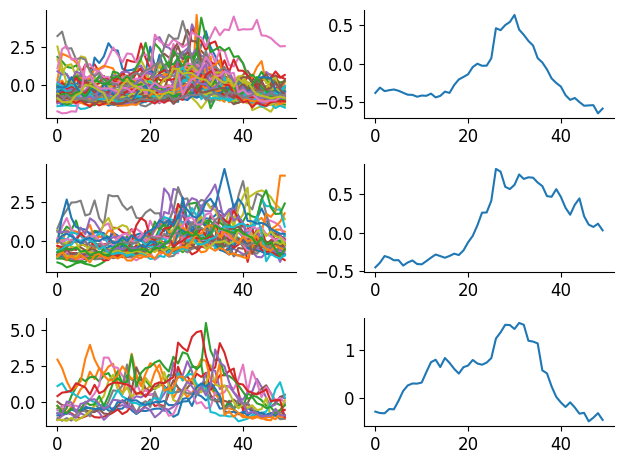

In [72]:

actual_2d_data = fixed_activity_dict_NDNF_newest['animal_19']["cell_3"]

fig, axs = plt.subplots(3,2)
for cluster_num in range(3):
    labels_example_TT_0 = np.where(labels_example==cluster_num)[0]
    sliced_data = actual_2d_data[:,labels_example_TT_0]

    for i in range(sliced_data.shape[1]):
        axs[cluster_num,0].plot(sliced_data[:,i])
    axs[cluster_num,1].plot(np.mean(sliced_data, axis=1))

plt.tight_layout()    
plt.show()

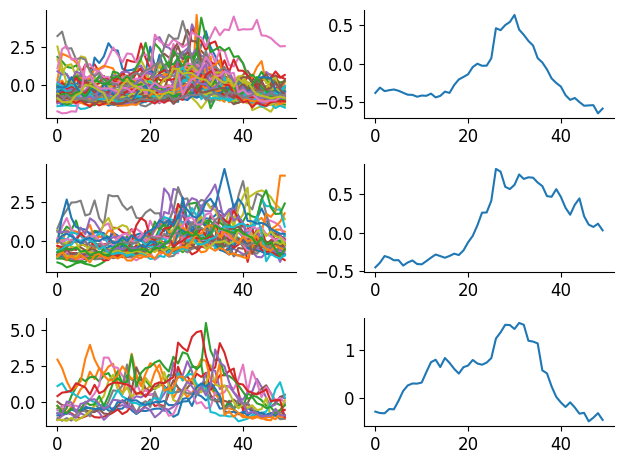

In [ ]:

actual_2d_data = fixed_activity_dict_NDNF_newest['animal_19']["cell_3"]

fig, axs = plt.subplots(3,2)
for cluster_num in range(3):
    labels_example_TT_0 = np.where(labels_example==cluster_num)[0]
    sliced_data = actual_2d_data[:,labels_example_TT_0]

    for i in range(sliced_data.shape[1]):
        axs[cluster_num,0].plot(sliced_data[:,i])
    axs[cluster_num,1].plot(np.mean(sliced_data, axis=1))

plt.tight_layout()    
plt.show()

In [46]:
cells_TT_group_0_list = []
cells_TT_group_1_list = []

count=0
all_NDNF_cells_TT_data_list = []
for animal in fixed_TT_data:
    for cell in range(len(fixed_TT_data[animal])):
        if count in cells_group_0:
            cells_TT_group_0_list.append(fixed_TT_data[animal][cell][1][f"cell_{cell}"]["indices_for_cluster_number"]['clusters_chosen_3'])
        else:
            cells_TT_group_1_list.append(fixed_TT_data[animal][cell][1][f"cell_{cell}"]["indices_for_cluster_number"]['clusters_chosen_3'])
        count+=1

print(len(cells_TT_group_0_list))
print(len(cells_TT_group_1_list))

59
56


In [73]:
print(cells_TT_group_0_list)

[{0: array([  1,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  24,  27,  28,  29,  30,
        32,  33,  39,  40,  41,  42,  47,  48,  59,  67,  69,  70,  92,
       106]), 1: array([  0,   2,   8,  26,  31,  34,  36,  38,  43,  46,  49,  53,  56,
        58,  60,  61,  62,  63,  65,  71,  72,  74,  79,  80,  81,  83,
        85,  86,  93,  95,  99, 101, 104]), 2: array([ 25,  35,  37,  44,  45,  50,  51,  52,  54,  55,  57,  64,  66,
        68,  73,  75,  76,  77,  78,  82,  84,  87,  88,  89,  90,  91,
        94,  96,  97,  98, 100, 102, 103, 105])}, {0: array([  4,   5,   8,   9,  11,  13,  14,  15,  16,  18,  20,  22,  23,
        24,  25,  26,  28,  29,  30,  31,  32,  34,  35,  36,  38,  39,
        41,  44,  45,  46,  47,  48,  49,  50,  51,  52,  56,  57,  58,
        61,  63,  66,  67,  68,  69,  70,  71,  73,  74,  76,  77,  79,
        80,  81,  82,  83,  85,  86,  87,  88,  90,  91,  93,  94,  95,
        96,  

In [ ]:
############ which trial type was the most expressed early, middle, late -- then look at its activity 
## can do sliding window later but its not necessary 

cell=0
cells_TT_group_0_list[cell]

{0: array([  1,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,  14,  15,
         16,  17,  18,  19,  20,  21,  22,  23,  24,  27,  28,  29,  30,
         32,  33,  39,  40,  41,  42,  47,  48,  59,  67,  69,  70,  92,
        106]),
 1: array([  0,   2,   8,  26,  31,  34,  36,  38,  43,  46,  49,  53,  56,
         58,  60,  61,  62,  63,  65,  71,  72,  74,  79,  80,  81,  83,
         85,  86,  93,  95,  99, 101, 104]),
 2: array([ 25,  35,  37,  44,  45,  50,  51,  52,  54,  55,  57,  64,  66,
         68,  73,  75,  76,  77,  78,  82,  84,  87,  88,  89,  90,  91,
         94,  96,  97,  98, 100, 102, 103, 105])}